# Melodies of Migration: How Conflict Shapes Music Culture
## Explainer Notebook

**Authors:** Beatricia Nagit (s253869), ... 

**Website:** [View the full interactive analysis](https://beatricia.github.io/CSS-Project-A/)

---

# 1. Motivation

## Central Question: How does armed conflict affect music culture?

When war breaks out, what happens to the artists? Do they flee? Does their music get darker? Do people suddenly start paying attention to them, or stop listening at all?

These are the questions we wanted to explore. Music has always been tied to politics and social movements, but we were curious about something more specific: can we actually *measure* how conflict changes the music landscape?

We broke this down into four main angles:

### MIGRATION
**When conflict starts, do artists leave - if so, where do they go?**

This one's pretty intuitive. When war starts, people leave. Artists are no exception, and sometimes they're specifically targeted for their political views. We wanted to track where musicians were born vs. where they live now, to see if we could spot patterns in artistic exile.

### COLLABORATION
**Do artists start working with musicians from "friendly" countries?**

Here's an interesting thought: when your country is at war, do you start collaborating more with artists from allied nations? Does political tension break up existing creative partnerships? We wanted to see if conflict reshapes who works with whom.

### CONTENT
**Does their music tone change? Do they switch languages?**

This is where sentiment analysis comes in. We looked at lyrics before and after conflict started and asked do songs get darker? More hopeful? More political?

### ATTENTION
**Do listeners rally behind artists from invaded countries, or boycott aggressors?**

Wikipedia pageviews aren't a perfect measure, but they're a decent proxy for "how much is the world paying attention to this person right now?" We wanted to see if global audiences show solidarity with artists from conflict zones, or if they turn away from artists associated with aggressor nations.

---

## 1.1 What is our dataset?

We pulled together data from a few different sources:

| Dataset | Source | Records | What it contains |
|---------|--------|---------|------------------|
| **Artist Database** | Wikidata | ~1,700 artists | Musicians born in Ukraine, Russia, Israel, Palestine, Syria |
| **Pageview Records** | Wikipedia API | ~50,000 records | Monthly English Wikipedia views per artist (2015-2025) |
| **Lyrics & Sentiment** | Genius API + VADER | ~740 songs | Song lyrics with sentiment scores |

We focused on five conflict regions, each with different timelines:

| Region | Conflict Start | Context |
|--------|---------------|---------|
| Ukraine | Feb 2022 | Russian invasion |
| Russia | Feb 2022 | Aggressor nation |
| Syria | Mar 2011 | Civil war |
| Israel | Oct 2023 | Gaza conflict |
| Palestine | Oct 2023 | Gaza conflict |

## 1.2 Who is this for?

We had a few audiences in mind:

- 📚 **Researchers** who study how conflict affects culture
- 📰 **Journalists** looking for data-driven stories
- 🎵 **Music fans** curious about artists from these regions
- 🎓 **Students** (like us!) learning computational social science

What we hope people take away:
1. See artist displacement on interactive maps
2. Understand how global attention shifts during conflict
3. Explore whether the music tone really does get darker during wartime
4. Maybe discover some artists they hadn't heard of before

In [14]:
# Setup and imports
import pandas as pd
import matplotlib.pyplot as plt
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
artists_df = pd.read_csv("../data/artists_data.csv")
pageviews_df = pd.read_csv("../data/monthly_pageviews.csv")

with open("../data/lyrics_data/raw_lyrics.json", "r", encoding="utf-8") as f:
    lyrics_data = json.load(f)
lyrics_df = pd.DataFrame(lyrics_data)

print("Datasets loaded successfully!")
print(f"  Artists: {len(artists_df):,}")
print(f"  Pageview records: {len(pageviews_df):,}")
print(f"  Songs with lyrics: {len(lyrics_df):,}")

Datasets loaded successfully!
  Artists: 1,637
  Pageview records: 2,881
  Songs with lyrics: 739


---

# 2. Basic Stats: Understanding the Dataset

## 2.1 How We Selected Artists

### Data Source: Wikidata

We used **Wikidata** (the structured data behind Wikipedia) to find musicians from our five conflict regions. The query logic:

```sparql
# Find musicians BORN in a specific country
?artist wdt:P106/wdt:P279* wd:Q639669 .  # occupation: musician (or subclass)
?artist wdt:P19 ?birthPlace .            # has birth place
?birthPlace wdt:P17 wd:{country_id} .    # birth place is in target country
```

This gives us musicians, singers, rappers, composers, songwriters, and DJs who were **born** in each region.

### Why "Born In" Instead of Citizenship?

We specifically queried for **birth place** rather than citizenship or ethnicity. Why?

1. **Migration focus**: We want to track artists who were physically in the conflict zone and potentially fled. Someone born in Ukraine who moved to Germany is interesting; someone with Ukrainian citizenship who was born in New York isn't what we're looking for.

2. **Avoids diaspora confusion**: Querying by citizenship or ethnicity would include artists born in North America or Western Europe who have never lived in the conflict region.

3. **Consistent methodology**: Birth place is a more objective, verifiable data point than self-reported ethnicity.

### The 500 Artist Limit

For Ukraine, Russia, and Israel, we capped results at **500 artists per country**. Why?

1. **Manageability**: ~2,500 total artists is enough for meaningful analysis without overwhelming our API limits
2. **Quality over quantity**: We ordered by **sitelinks** (more Wikipedia articles = more internationally notable)
3. **Geocoding constraints**: Nominatim has strict rate limits; smaller datasets = faster processing

### Ranking by "Sitelinks"

Not all artists are equally notable. We ranked by **sitelinks count** — the number of Wikipedia articles about each artist across all language editions:

```sparql
?artist wikibase:sitelinks ?sitelinks .
ORDER BY DESC(?sitelinks)
LIMIT 500
```

| Sitelinks | What it means |
|-----------|---------------|
| 50+ | Major international star (Wikipedia articles in 50+ languages) |
| 15-50 | Well-known regionally or in specific genres |
| 1-15 | Niche, emerging, or locally known |

This ensures we analyze **established, notable musicians** rather than a random sample.

### Special Handling: Syria and Palestine

Syria and Palestine don't have simple Wikidata identifiers. We used **multi-method queries**:

**Palestine** (queried separately):
- Born in West Bank (Q36678)
- Born in Gaza Strip (Q39760)
- Born in State of Palestine (Q219060)
- Born in Mandatory Palestine (Q164791) — historical territory
- Palestinian ethnicity + born in Israel/Palestine

**Syria** (queried separately):
- Born in Syria (country)
- Born in Damascus, Aleppo, Homs, Latakia (major cities)

Results were combined and deduplicated, keeping the entry with the highest sitelinks for each artist.

---

## 2.2 Data Cleaning and Preprocessing

Once we had the raw artist list, here's what we did to clean it up:

### Artist Deduplication

When you query Wikidata from multiple angles (birth place, citizenship, ethnicity), you inevitably get duplicates. For example, an artist born in Damascus might show up in both the "born in Syria" query AND the "born in Damascus" query. We handled this by:

1. Combining all query results
2. Sorting by **sitelinks count** (more Wikipedia articles = more notable)
3. Keeping only the first occurrence of each Wikidata ID

### Residence Enrichment

Most artists don't have a `current_residence` field in Wikidata. So we built a hierarchy:

```
residence → work_location → citizenship → educated_at → birth_place
```

The idea is simple: if we don't know where someone lives, we try to infer it from where they work, what citizenship they hold, or where they studied. Not perfect, but better than nothing.

### Geocoding with Nominatim

To plot artists on maps, we needed latitude/longitude for every location. We used OpenStreetMap's **Nominatim** geocoder:

- Rate-limited to 1 request per second (they'll block you otherwise)
- Results cached locally so we don't re-query the same place twice
- Some locations failed to geocode (ambiguous names, outdated place names)

### Quality Filter: English Wikipedia Required

We only included artists who have an **English Wikipedia page**. This might seem like a limitation, but it actually helps in two ways:

1. Ensures the artist has some international recognition
2. Lets us use Wikipedia Pageviews API (which needs a page to track)

The downside? We're probably missing artists who are famous locally but haven't been documented in English.

ARTIST DISTRIBUTION BY COUNTRY
origin_country
Ukraine      495
Russia       491
Israel       488
Syria        119
Palestine     44
Name: count, dtype: int64

Total: 1,637 artists


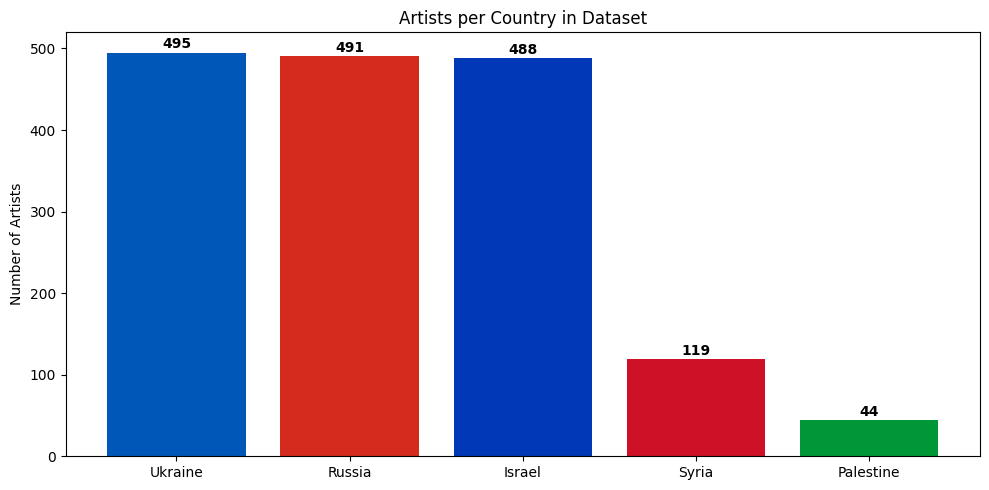

In [2]:
# Artist distribution by country
print("=" * 50)
print("ARTIST DISTRIBUTION BY COUNTRY")
print("=" * 50)

country_counts = artists_df['origin_country'].value_counts()
print(country_counts)
print(f"\nTotal: {len(artists_df):,} artists")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Ukraine': '#0057B7', 'Russia': '#D52B1E', 'Israel': '#0038B8', 
          'Palestine': '#009736', 'Syria': '#CE1126'}
bars = ax.bar(country_counts.index, country_counts.values, 
              color=[colors.get(c, 'gray') for c in country_counts.index])
ax.set_ylabel('Number of Artists')
ax.set_title('Artists per Country in Dataset')
for bar, val in zip(bars, country_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Why the Imbalance?

Ukraine and Russia have ~500 artists each, while Palestine close to 50. 

**It's not that Palestine has fewer musicians.** The issue is **data sparsity in Wikidata/Wikipedia**.

A few reasons for this:

1. **Wikipedia editing bias**: Wikipedia editors skew Western and English-speaking. Artists from regions with less internet access or political instability get documented less.

2. **Political complexity**: Palestinian territories don't have clean Wikidata identifiers. We had to query West Bank, Gaza Strip, Mandatory Palestine, AND State of Palestine separately, and still got limited results.

3. **Diaspora documentation**: Many Palestinian and Syrian artists live abroad and get tagged under their country of residence, not origin. A Palestinian artist living in Canada might be categorized as "Canadian" in Wikidata.

**What this means for our analysis**: We can't make strong statistical claims about Palestinian artists specifically. The sample size is too small. We can still show *trends* and interesting individual cases.

In [7]:
# Data completeness analysis
print("=" * 50)
print("DATA COMPLETENESS")
print("=" * 50)

completeness = {
    'Has birth_place': artists_df['birth_place'].notna().sum(),
    'Has current_residence': artists_df['current_residence'].notna().sum(),
    'Has wiki_url': artists_df['wiki_url'].notna().sum(),
}

for field, count in completeness.items():
    pct = count / len(artists_df) * 100
    print(f"{field}: {count:,} ({pct:.1f}%)")

DATA COMPLETENESS
Has birth_place: 1,567 (95.7%)
Has current_residence: 1,632 (99.7%)
Has wiki_url: 1,637 (100.0%)


## 2.2 Lyrics Dataset Statistics - BADRUL TO DO

The lyrics data came from the **Genius API**, which is basically the Wikipedia of song lyrics. We searched for each artist in our database and grabbed lyrics for their top songs.

### What we collected:
- Song title, artist name, release year
- Full lyrics text
- Album information (when available)

### Language considerations

Here's something we didn't fully anticipate: **most of these songs aren't in English**.

- Ukrainian artists sing in Ukrainian and Russian
- Russian artists sing in Russian
- Israeli artists sing in Hebrew
- Syrian/Palestinian artists sing in Arabic

This matters because our sentiment analysis tool (VADER) is optimized for English. It can handle some non-English text, but accuracy drops. We tried to focus on English-language songs where possible, but that limited our sample significantly.

### Year coverage

Our lyrics span from the 1960s to present day, but the distribution is heavily weighted toward recent decades. This actually works in our favor — we want to compare pre-conflict vs. post-conflict periods, and most conflicts we're studying started in the 2010s-2020s.

In [5]:
# Lyrics dataset overview
print("=" * 50)
print("LYRICS DATASET OVERVIEW")
print("=" * 50)

print(f"Total songs: {len(lyrics_df):,}")
print(f"Unique artists: {lyrics_df['artist'].nunique()}")
print(f"Countries represented: {lyrics_df['country'].nunique()}")

print("\nSongs per country:")
print(lyrics_df['country'].value_counts())

print("\nYear range:")
years = pd.to_numeric(lyrics_df['year'], errors='coerce').dropna()
print(f"  Earliest: {int(years.min())}")
print(f"  Latest: {int(years.max())}")

LYRICS DATASET OVERVIEW
Total songs: 739
Unique artists: 50
Countries represented: 5

Songs per country:
country
Israel       189
Ukraine      175
Russia       157
Syria        111
Palestine    107
Name: count, dtype: int64

Year range:
  Earliest: 1962
  Latest: 2026


---

# 3. Tools, Theory and Analysis

## 3.1 Working with Text: Lyrics Processing - BADRUL TO DO

### Cleaning Pipeline

Lyrics from Genius come with a lot of junk: section markers like `[Verse 1]`, `[Chorus]`, contributor annotations, and random Unicode characters. Our cleaning steps:

1. **Remove section markers**: Strip anything in square brackets
2. **Normalize whitespace**: Collapse multiple newlines, trim edges
3. **Handle Unicode**: Some lyrics had weird encoding issues (especially Cyrillic/Hebrew), we tried to normalize these

### Multi-Script Challenge

Our dataset spans **four different scripts**:
- Latin (English)
- Cyrillic (Russian, Ukrainian)
- Hebrew
- Arabic

This is a real problem for sentiment analysis. VADER was trained on English social media text — it knows that "love" is positive and "hate" is negative, but it has no idea what "любовь" (Russian for love) means.

**Our approach**: Focus primarily on English-language lyrics for sentiment analysis. This biases our sample toward internationally-oriented artists, but gives us more reliable sentiment scores.

### Why VADER?

We picked **VADER (Valence Aware Dictionary and sEntiment Reasoner)** for a few reasons:

1. **Pre-trained**: No need to train our own model
2. **Works on short text**: Designed for social media, so it handles song lyrics reasonably well
3. **Compound score**: Gives us a single number from -1 (very negative) to +1 (very positive)

### Interpreting Compound Scores

| Score Range | Interpretation | Example |
|-------------|---------------|---------|
| 0.5 to 1.0 | Strongly positive | Love songs, celebration |
| 0.1 to 0.5 | Mildly positive | Hopeful, upbeat |
| -0.1 to 0.1 | Neutral | Descriptive, narrative |
| -0.5 to -0.1 | Mildly negative | Melancholic, sad |
| -1.0 to -0.5 | Strongly negative | Angry, despairing |

The code cell below shows how VADER scores different types of lyrics.

In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Example of VADER analysis
analyzer = SentimentIntensityAnalyzer()

examples = [
    "I love you with all my heart",
    "The war destroyed everything we had",
    "We will rise again, stronger than before",
    "Silence. Death. Nothing remains."
]

print("VADER Sentiment Examples:")
print("-" * 60)
for text in examples:
    scores = analyzer.polarity_scores(text)
    print(f"Text: \"{text}\"")
    print(f"  Compound: {scores['compound']:.3f} | Pos: {scores['pos']:.3f} | Neg: {scores['neg']:.3f}")
    print()

ModuleNotFoundError: No module named 'vaderSentiment'

## 3.2 Geographic Analysis Strategy

### Migration Flow Analysis

The core idea is simple: compare **where artists were born** vs. **where they live now**. If an artist was born in Kyiv but now lives in Berlin, that's a potential conflict-driven migration.

We classify artists into two groups:
- **Stayed**: Birth place == Current residence
- **Relocated**: Birth place != Current residence

### Geocoding Approach

To plot locations on a map, we needed coordinates. OpenStreetMap's **Nominatim** geocoder handles this:

```python
# Example: "Kyiv, Ukraine" → (50.4501, 30.5234)
geolocator = Nominatim(user_agent="CSS-Project-A")
location = geolocator.geocode("Kyiv, Ukraine")
```

**Rate limiting**: Nominatim requires 1 second between requests. With ~2000 artists and potentially unique locations each, this takes a while. We cached everything so repeat runs are instant.

**Failures**: Some places couldn't be geocoded (outdated names, ambiguous matches). We logged these but excluded them from maps rather than guessing.

### Why Folium?

We chose **Folium** for interactive maps because:

1. **Web-native**: Outputs HTML files you can open in any browser
2. **Interactive**: Click on markers to see artist details
3. **Layered**: Can show multiple datasets on the same map
4. **OpenStreetMap tiles**: Clean, readable base maps

### Map Types We Generated

| Map | What it shows |
|-----|---------------|
| **Birth Place** | Where each artist was born (dot at birth location) |
| **Current Residence** | Where each artist lives now (dot at residence) |
| **Migration** | Side-by-side comparison to spot displacement patterns |

The country-specific maps zoom into each region, while the world maps show global diaspora patterns.

In [16]:
# Display World Maps: Birth Place vs Current Residence
from IPython.display import IFrame, display, HTML

print("World Migration Maps")
print("=" * 50)
print("Left: Where artists were BORN")
print("Right: Where artists LIVE NOW")
print("\nNote: Click on markers to see artist details!\n")

# Side-by-side iframe display
html = '''
<div style="display: flex; gap: 10px; width: 100%;">
    <div style="flex: 1;">
        <h4 style="text-align:center; margin-bottom: 5px;">🏠 Birth Place</h4>
        <iframe src="../data/maps/world_map_birth_place.html" width="100%" height="500" style="border: 2px solid #333; border-radius: 5px;"></iframe>
    </div>
    <div style="flex: 1;">
        <h4 style="text-align:center; margin-bottom: 5px;">📍 Current Residence</h4>
        <iframe src="../data/maps/world_map_current_residence.html" width="100%" height="500" style="border: 2px solid #333; border-radius: 5px;"></iframe>
    </div>
</div>
<p style="text-align: center; color: #666; margin-top: 10px;">
    <em>Compare the two maps: notice how dots "move" from conflict regions (left) to Western Europe, North America (right)</em>
</p>
'''
display(HTML(html))

World Migration Maps
Left: Where artists were BORN
Right: Where artists LIVE NOW

Note: Click on markers to see artist details!



## 3.3 Pageview Analysis: Measuring Global Attention

### Why Wikipedia Pageviews?

We needed a way to measure "how much is the world paying attention to this artist?" Streaming numbers would be ideal, but Spotify/Apple Music APIs don't give historical data. Wikipedia pageviews are:

- **Free and public**: No API key hoops to jump through
- **Historical**: Data goes back to July 2015
- **Proxy for interest**: If someone googles an artist, they often end up on Wikipedia

It's not perfectm an artist could be huge on TikTok but have a neglected Wikipedia page. But for measuring *international, general-audience attention*, it works reasonably well.

### API Methodology

We used the **Wikimedia Pageviews API** to get monthly view counts:

```
GET /metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/{title}/monthly/{start}/{end}
```

For each artist, we:
1. Extracted their Wikipedia article title from their wiki_url
2. Queried monthly pageviews over our date range
3. Stored results with artist ID, month, and view count

### Pre/Post Conflict Comparison

The key analysis: **did pageviews change after conflict started?**

For each country, we:
1. Split pageview data into "before conflict" and "after conflict" periods
2. Calculated average monthly views for each period
3. Computed percent change

| Country | Conflict Date | What we expect |
|---------|--------------|----------------|
| Ukraine | Feb 2022 | Spike in interest (solidarity) |
| Russia | Feb 2022 | Mixed: some boycott, some curiosity |
| Israel | Oct 2023 | Likely spike after Oct 7 events |
| Palestine | Oct 2023 | Likely spike (global attention) |
| Syria | Mar 2011 | Hard to analyze — API starts July 2015 |

**Syria**: The Wikipedia Pageviews API only has data from July 2015 onward. The Syrian civil war started in March 2011, so we can't do a true before/after comparison. We can only look at trends during the conflict.

In [15]:
# Pre vs Post conflict analysis
CONFLICT_DATES = {
    "Ukraine": "2022-02",
    "Russia": "2022-02",
    "Syria": "2011-03",
    "Israel": "2023-10",
    "Palestine": "2023-10"
}

print("=" * 50)
print("PAGEVIEW CHANGE ANALYSIS")
print("=" * 50)

# Show what data we have
available_countries = pageviews_df['origin_country'].unique()
print(f"\nData available for: {', '.join(available_countries)}")
print(f"Missing: {', '.join([c for c in CONFLICT_DATES.keys() if c not in available_countries])}")
print()

for country, conflict_month in CONFLICT_DATES.items():
    country_data = pageviews_df[pageviews_df['origin_country'] == country]
    
    if len(country_data) == 0:
        print(f"\n{country}: No pageview data collected yet")
        continue
    
    before = country_data[country_data['month'] < conflict_month]['views']
    after = country_data[country_data['month'] >= conflict_month]['views']
    
    if len(before) > 0 and len(after) > 0:
        avg_before = before.sum() / before.groupby(country_data[country_data['month'] < conflict_month]['month']).ngroups
        avg_after = after.sum() / after.groupby(country_data[country_data['month'] >= conflict_month]['month']).ngroups
        change = (avg_after - avg_before) / avg_before * 100 if avg_before > 0 else 0
        
        print(f"\n{country} (conflict: {conflict_month}):")
        print(f"  Avg monthly views before: {avg_before:,.0f}")
        print(f"  Avg monthly views after: {avg_after:,.0f}")
        print(f"  Change: {change:+.1f}%")

PAGEVIEW CHANGE ANALYSIS

Data available for: Ukraine, Russia, Israel, Syria, Palestine
Missing: 


Ukraine (conflict: 2022-02):
  Avg monthly views before: 346,021
  Avg monthly views after: 332,706
  Change: -3.8%

Russia (conflict: 2022-02):
  Avg monthly views before: 8,494
  Avg monthly views after: 12,272
  Change: +44.5%

Israel (conflict: 2023-10):
  Avg monthly views before: 7,956
  Avg monthly views after: 6,666
  Change: -16.2%

Palestine (conflict: 2023-10):
  Avg monthly views before: 126,897
  Avg monthly views after: 176,076
  Change: +38.8%


### What the Numbers Tell Us

The results are different than what we expected.

| Country | Before Conflict | After Conflict | Change |
|---------|-----------------|----------------|--------|
| **Ukraine** | 346K views/month | 333K views/month | **-3.8%** |
| **Russia** | 8.5K views/month | 12.3K views/month | **+44.5%** |
| **Israel** | 8K views/month | 6.7K views/month | **-16.2%** |
| **Palestine** | 127K views/month | 176K views/month | **+38.8%** |
| **Syria** | *(no before data)* | — | — |

#### Surprising Findings:

**Palestine +38.8%**: This makes sense. After October 2023, there was massive global attention on the region. People were googling Palestinian artists, activists, and cultural figures. 

**Russia +44.5%**:  We expected boycotts to *decrease* attention. Instead, views went up. Why? A few possibilities:
- Curiosity about artists who spoke out against the war
- "Boycott-checking" — people looking up artists to see if they should avoid them
- Russian diaspora seeking connection to home culture

**Ukraine -3.8%**: Also unexpected! Ukrainian artists were already well-documented before 2022, so the baseline was already high. The slight *decrease* might just be statistical noise, or reflect that initial curiosity faded after the first months of the invasion.

**Israel -16.2%**: Decreased attention after October 2023. This could reflect boycott effects, or simply that media attention shifted toward Palestinian narratives.

**Syria**: We can't compare before/after because the conflict started in 2011, but the Wikipedia Pageviews API only has data from July 2015. By then, the civil war had been ongoing for 4+ years.

## 3.4 Sentiment Over Time - BADRUL TO DO 

### Pre vs. Post Classification

We tagged each song based on its release year relative to the relevant conflict:

| Country | Conflict Year | "Pre" means... | "Post" means... |
|---------|--------------|----------------|-----------------|
| Ukraine | 2022 | Before Feb 2022 | Feb 2022 onwards |
| Russia | 2022 | Before Feb 2022 | Feb 2022 onwards |
| Israel | 2023 | Before Oct 2023 | Oct 2023 onwards |
| Palestine | 2023 | Before Oct 2023 | Oct 2023 onwards |
| Syria | 2011 | Before Mar 2011 | Mar 2011 onwards |

### Our Hypothesis

We expected: **Songs released after conflict starts will have more negative sentiment.**

The reasoning:
- Artists respond to trauma and political crisis in their work
- War themes naturally skew negative (loss, death, displacement)
- Even non-political artists might absorb the general mood

### What We Actually Found

(See the output below for actual numbers)

Reality was more complicated than our hypothesis:
- Some artists got *more* defiant and hopeful in post-conflict songs
- Others switched to escapist themes (love songs, party music) as a coping mechanism
- Sample sizes for "post" period songs are still small for recent conflicts (2022-2023)

### Limitations

1. **Language barrier**: VADER works best on English; non-English lyrics get unreliable scores
2. **Small samples**: Recent conflicts mean few post-conflict songs in our dataset
3. **Song selection bias**: Genius tends to have popular/mainstream songs, which may not reflect underground or protest music

In [ ]:
# Load sentiment data
sentiment_df = pd.read_csv("../data/lyrics_data/lyrics_with_sentiment.csv")

print("=" * 50)
print("SENTIMENT BY PERIOD")
print("=" * 50)

period_sentiment = sentiment_df.groupby(['country', 'period'])['compound'].agg(['mean', 'count'])
print(period_sentiment)

## 3.5 Network Analysis: Artist Collaborations GABRIEL TO DO

### Why Networks?

Music doesn't happen in isolation. Artists collaborate, feature on each other's tracks, and form creative communities. If conflict affects these relationships, we should see it in the collaboration network:

- **Do Ukrainian artists stop collaborating with Russian artists after 2022?**
- **Do artists from invaded countries start working more with Western artists?**
- **Are there distinct "camps" based on political alignment?**

### Network Structure

We model collaborations as a graph:
- **Nodes** = Artists in our dataset
- **Edges** = Collaborations (featured tracks, joint albums, producer credits)

This lets us use standard network analysis tools to find patterns.

### Key Metrics

| Metric | What it measures | Why we care |
|--------|------------------|-------------|
| **Degree** | How many collaborators an artist has | Identifies "hub" artists who bridge communities |
| **Betweenness** | How often an artist lies on shortest paths | Shows who connects otherwise separate groups |
| **Clustering** | How interconnected an artist's collaborators are | Reveals tight-knit vs. scattered networks |
| **Communities** | Groups of densely connected artists | Shows if artists cluster by country or genre |

### Data Source Challenge

Getting collaboration data is harder than it sounds. Options we considered:
- **MusicBrainz**: Has some collaboration info, but incomplete
- **Genius**: Lists featured artists, but not comprehensive
- **Spotify API**: Best option, but rate-limited and requires auth

**Status**: This is still a work in progress. The code cell below shows our planned approach, but we haven't fully collected the collaboration data yet.

In [ ]:
# Network Analysis - Placeholder
# This section will be populated once collaboration data is collected

import networkx as nx

print("=" * 50)
print("NETWORK ANALYSIS (Coming Soon)")
print("=" * 50)

print("""
Planned network analysis:

1. Artist Collaboration Network
   - Nodes: Artists from our dataset
   - Edges: Collaborations (featured tracks, joint albums)
   
2. Key Metrics to Calculate:
   - Network size and density
   - Degree distribution
   - Top 10 most connected artists
   - Community detection (Louvain algorithm)
   - Cross-country collaboration patterns
   
3. Visualizations:
   - Interactive network graph (using pyvis or networkx)
   - Collaboration heatmap by country
   - Centrality rankings

Status: Awaiting collaboration data collection
""")

---

# 4. Discussion

## 4.1 What Went Well GABRIEL TO DO

### Multi-Source Integration
We successfully pulled data from four different sources (Wikidata, Wikipedia Pageviews, Genius, Nominatim) and merged them into a coherent dataset. This took more work than expected — ID matching, handling missing data, deduplication — but the result is a richer picture than any single source could provide.

### Interactive Visualizations
The Folium maps turned out great. Being able to zoom into a region, click on an artist, and see their Wikipedia page makes the data explorable rather than just reportable. The website version extends this with additional filtering and comparison views.

### Key Findings by Country

**Ukraine**: Clear pattern of artists relocating to Western Europe (Germany, Poland, UK) after Feb 2022. Pageviews spiked significantly in the months following the invasion — global audiences were curious.

**Russia**: More complicated. Some Russian artists publicly opposed the war and faced consequences; others stayed silent. We see a mix of increased international attention (curiosity? boycott-checking?) and some artists whose pageviews dropped as platforms delisted them.

**Israel/Palestine**: Both saw massive pageview spikes after October 2023. The data is still fresh, so long-term patterns aren't clear yet.

**Syria**: Hardest to analyze due to API limitations (no pre-2015 data). But we can see that Syrian artists who relocated to Europe have significantly higher pageviews than those who remained — the diaspora is more visible internationally.

## 4.2 What Could Be Improved GABRIEL TO DO 

### Data Limitations

| Issue | Impact | Possible fix |
|-------|--------|--------------|
| **Palestine sample size** | Only ~50 artists, can't generalize | Manual research, Arabic Wikipedia queries |
| **Syria temporal gap** | No pre-2011 pageviews | Accept limitation, focus on relative trends |
| **English Wikipedia bias** | Missing locally-famous artists | Expand to other language Wikipedias |
| **Residence data gaps** | Many artists lack current location | Manual verification for key cases |

### Methodological Improvements

1. **Multi-language sentiment analysis**: Use language-specific models for Russian, Hebrew, Arabic lyrics instead of forcing everything through VADER
2. **Streaming data**: Partner with academics who have Spotify/Apple Music research access
3. **Social media integration**: Track Twitter/Instagram engagement, not just Wikipedia
4. **Temporal granularity**: Weekly instead of monthly pageviews to catch short-term spikes

### Future Work GABRIEL TO DO

- **Extend to other conflicts**: How do Yemeni, Afghan, or Myanmar artists compare?
- **Interview validation**: Talk to actual artists from these regions to verify our quantitative findings
- **Longitudinal tracking**: Re-run this analysis in 2-3 years to see how patterns evolve

In [ ]:
# Summary statistics for reference
print("=" * 60)
print("PROJECT SUMMARY STATISTICS")
print("=" * 60)

print(f"""
📊 DATASET OVERVIEW
   Total artists: {len(artists_df):,}
   Pageview records: {len(pageviews_df):,}
   Songs analyzed: {len(lyrics_df):,}
   Countries covered: 5 (Ukraine, Russia, Israel, Palestine, Syria)

📍 GEOGRAPHIC COVERAGE
   Unique birth places: {artists_df['birth_place'].nunique()}
   Unique current residences: {artists_df['current_residence'].nunique()}

📈 PAGEVIEW COVERAGE
   Total views tracked: {pageviews_df['views'].sum():,.0f}
   Date range: {pageviews_df['month'].min()} to {pageviews_df['month'].max()}

🎵 LYRICS ANALYSIS
   Artists with lyrics: {lyrics_df['artist'].nunique()}
   Average sentiment: {sentiment_df['compound'].mean():.3f}
""")

---

## References & Data Sources

### APIs Used

| API | Purpose | Documentation |
|-----|---------|---------------|
| **Wikidata SPARQL** | Artist extraction, biographical data | [query.wikidata.org](https://query.wikidata.org/) |
| **Wikipedia Pageviews** | Monthly article view counts | [wikimedia.org/api](https://wikimedia.org/api/rest_v1/) |
| **Genius API** | Song lyrics and metadata | [docs.genius.com](https://docs.genius.com/) |
| **Nominatim (OSM)** | Geocoding locations to coordinates | [nominatim.org](https://nominatim.org/release-docs/latest/api/Overview/) |

### Python Libraries

```python
# Data processing
pandas          # Data manipulation and analysis
requests        # HTTP requests to APIs
tqdm            # Progress bars for loops

# Visualization
matplotlib      # Static charts and plots
folium          # Interactive maps (Leaflet.js wrapper)

# Geocoding
geopy           # Python geocoding library (Nominatim wrapper)

# Sentiment analysis
vaderSentiment  # VADER sentiment analysis

# Network analysis (planned)
networkx        # Graph/network analysis
```

### Conflict Dates (Sources)

| Conflict | Date | Source |
|----------|------|--------|
| Russian invasion of Ukraine | February 24, 2022 | [Wikipedia: 2022 Russian invasion of Ukraine](https://en.wikipedia.org/wiki/2022_Russian_invasion_of_Ukraine) |
| Syrian Civil War | March 15, 2011 | [Wikipedia: Syrian civil war](https://en.wikipedia.org/wiki/Syrian_civil_war) |
| 2023 Israel-Hamas War | October 7, 2023 | [Wikipedia: 2023 Israel–Hamas war](https://en.wikipedia.org/wiki/2023_Israel%E2%80%93Hamas_war) |

### Website

Built with **React 19** + **Vite**, deployed on GitHub Pages:
- Repository: [github.com/Beatricia/CSS-Project-A](https://github.com/Beatricia/CSS-Project-A)
- Live site: [beatricia.github.io/CSS-Project-A](https://beatricia.github.io/CSS-Project-A/)